# 03 — Neural model training and convergence

This executable notebook trains the three headline neural encoders: **DriftMamba**, the **causal Transformer**, and the **xLSTM-inspired encoder**. Every run uses the same processed tensors, chronological calibration split, batch size, seed, and open-world threshold.

> Set `RUN_TRAINING = True` after preparing `data/processed/cesnet_quic22_xs`. Full training duration depends on the available CPU/GPU.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed' / 'cesnet_quic22_xs'
ARTIFACTS = ROOT / 'artifacts' / 'notebook_training'
REPORTS = ROOT / 'reports' / 'notebook_training'
RUN_TRAINING = False
ENCODERS = ['driftmamba', 'transformer', 'xlstm']
EPOCHS, BATCH_SIZE, ALPHA, SEED = 12, 256, 0.10, 42
plt.style.use('seaborn-v0_8-whitegrid')


## Train the three encoders

The project CLI performs optimization, early stopping, prototype fitting, conformal calibration, known/unknown evaluation, early-packet tests, and drift auditing. The ensemble is evaluated after the three independently trained models produce predictions.

In [2]:
commands = {}
for encoder in ENCODERS:
    commands[encoder] = [
        sys.executable, '-m', 'driftmamba.cli.train_deep',
        '--data-directory', str(DATA),
        '--models-directory', str(ARTIFACTS / encoder),
        '--reports-directory', str(REPORTS / encoder),
        '--encoder', encoder, '--epochs', str(EPOCHS),
        '--batch-size', str(BATCH_SIZE), '--alpha', str(ALPHA),
        '--seed', str(SEED),
    ]
display_commands = {name: ['python ' + ' '.join(command[1:])] for name, command in commands.items()}
pd.DataFrame(display_commands).T.rename(columns={0: 'command'})


,command
driftmamba,python -m driftmamba.cli.train_deep --data-dir...
transformer,python -m driftmamba.cli.train_deep --data-dir...
xlstm,python -m driftmamba.cli.train_deep --data-dir...


In [3]:
if RUN_TRAINING:
    required = ['train.npz', 'calibration.npz', 'test_known.npz', 'test_unknown.npz']
    missing = [name for name in required if not (DATA / name).exists()]
    if missing:
        raise FileNotFoundError(f'Prepare the processed dataset first; missing: {missing}')
    for encoder, command in commands.items():
        print(f'\nTraining {encoder} ...')
        subprocess.run(command, cwd=ROOT, check=True)
else:
    print('Training is disabled. Set RUN_TRAINING = True to create fresh checkpoints and reports.')


Training is disabled. Set RUN_TRAINING = True to create fresh checkpoints and reports.


## Training and calibration loss curves

These plots expose convergence and overfitting. Fresh notebook reports are preferred; otherwise the tracked verified training history is used for an immediately reproducible comparison.

In [4]:
histories = []
for encoder in ENCODERS:
    candidate = REPORTS / encoder / 'deep_metrics.json'
    if candidate.exists():
        payload = json.loads(candidate.read_text(encoding='utf-8'))
        histories.append(pd.DataFrame(payload['training_history']).assign(model=encoder))
history = (pd.concat(histories, ignore_index=True) if histories
           else pd.read_csv(ROOT / 'results' / 'training_history.csv'))
history.head()


,model,epoch,training_loss,calibration_loss
0,driftmamba,1,2.008204,1.693332
1,driftmamba,2,1.591499,1.488317
2,driftmamba,3,1.412628,1.473790
3,driftmamba,4,1.290454,1.260737
4,driftmamba,5,1.151433,1.181865


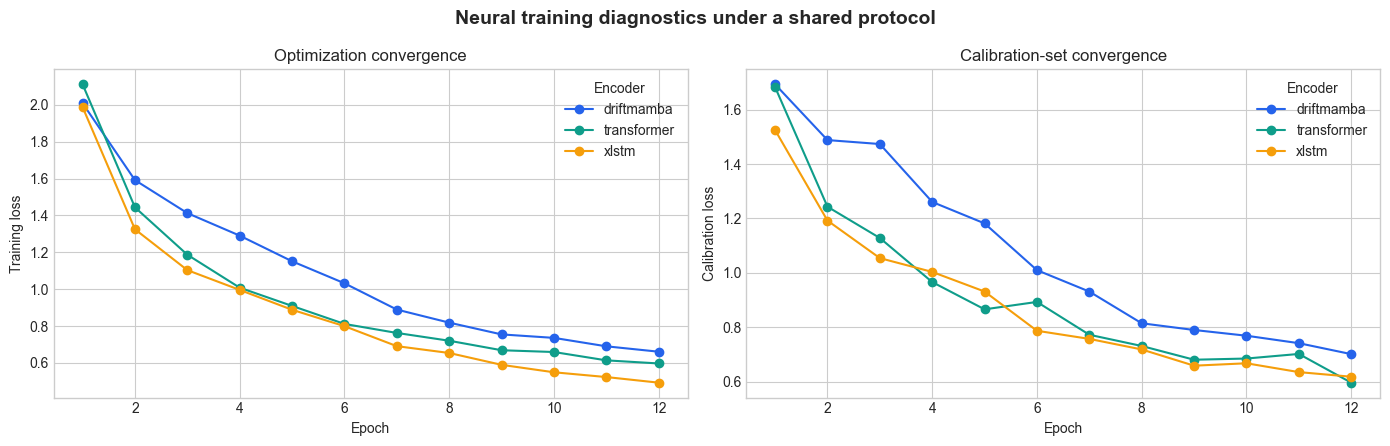

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colors = {'driftmamba': '#2563EB', 'transformer': '#0F9D8A', 'xlstm': '#F59E0B'}
for model, group in history.groupby('model'):
    axes[0].plot(group['epoch'], group['training_loss'], marker='o', label=model, color=colors[model])
    axes[1].plot(group['epoch'], group['calibration_loss'], marker='o', label=model, color=colors[model])
axes[0].set(title='Optimization convergence', xlabel='Epoch', ylabel='Training loss')
axes[1].set(title='Calibration-set convergence', xlabel='Epoch', ylabel='Calibration loss')
for ax in axes:
    ax.legend(title='Encoder')
fig.suptitle('Neural training diagnostics under a shared protocol', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


## Convergence summary

Checkpoint selection uses the lowest loss on the disjoint calibration partition rather than test performance.

In [6]:
summary = history.loc[history.groupby('model')['calibration_loss'].idxmin(), ['model', 'epoch', 'training_loss', 'calibration_loss']]
summary = summary.rename(columns={'epoch': 'best_epoch'}).sort_values('calibration_loss')
summary.style.format({'training_loss': '{:.4f}', 'calibration_loss': '{:.4f}'}).background_gradient(subset=['calibration_loss'], cmap='YlGn_r')


,model,best_epoch,training_loss,calibration_loss
23,transformer,12,0.5974,0.5961
35,xlstm,12,0.4932,0.6180
11,driftmamba,12,0.6611,0.7011
